# Lifetime PSA analysis | ages 1-100

This notebook displays the reusable lifetime PSA report. Calculations and plotting logic live under `app.notebook.psa`.

In [1]:
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

from app.notebook.psa import LIFETIME
from app.notebook.psa.presentation import render_table
from app.notebook.psa.report import PSAReport

report = PSAReport.load(LIFETIME)
print(f"{report.horizon.label}: {report.df.height:,} simulation rows")
print(f"WTP: {report.wtp:,.0f} IRR/QALY")

g++ not available, if using conda: `conda install gxx`


Lifetime horizon (ages 2–100): 160,000 simulation rows
WTP: 18,000,000,000 IRR/QALY


In [2]:
tables = report.tables()
sections = report.table_sections(tables=tables)
current_group = None
for section in sections:
    if section.group != current_group:
        display(Markdown(f"## {section.group}"))
        current_group = section.group
    if section.title != section.group:
        display(Markdown(f"### {section.title}"))
    display(HTML(render_table(section.data)))
    display(Markdown(report.interpret_table(section)))

## Calibration

### Expected and observed bleeding

time_horizon,sampling_method,regime,n_patients,expected_abr,realized_abr
lifetime,bayesian,on-demand,"10,000",22.961,20.643
lifetime,bayesian,prophylaxis,"10,000",3.737,3.674
lifetime,dirichlet,on-demand,"10,000",22.509,20.786
lifetime,dirichlet,prophylaxis,"10,000",3.769,3.712


**Interpretation.** Across the four base arms, expected ABR is 3.74 to 22.96 and simulated ABR is 3.67 to 20.79. The largest absolute difference is 2.32 bleeds/person-year.

**Conclusion.** This is the primary face-validity check that event generation reproduces the ABR inputs; differences should be judged together with the uncertainty and formal calibration diagnostics below.

### Uncertainty intervals

...

comparison,paired_iterations,selected_wtp,probability_ce_at_selected_wtp
lifetime prophylaxis bayesian vs lifetime on-demand bayesian,"10,000","18,000,000,000.000",0.069
lifetime prophylaxis dirichlet vs lifetime on-demand dirichlet,"10,000","18,000,000,000.000",0.006
lifetime prophylaxis bayesian ich_pooled vs lifetime on-demand bayesian ich_pooled,"10,000","18,000,000,000.000",0.072
lifetime prophylaxis dirichlet ich_pooled vs lifetime on-demand dirichlet ich_pooled,"10,000","18,000,000,000.000",0.008
lifetime prophylaxis bayesian weight_reduction_10 vs lifetime on-demand bayesian weight_reduction_10,"10,000","18,000,000,000.000",0.077
lifetime prophylaxis bayesian weight_reduction_20 vs lifetime on-demand bayesian weight_reduction_20,"10,000","18,000,000,000.000",0.086
lifetime prophylaxis bayesian weight_reduction_30 vs lifetime on-demand bayesian weight_reduction_30,"10,000","18,000,000,000.000",0.106
lifetime prophylaxis bayesian is_discounting vs lifetime on-demand bayesian is_discounting,"10,000","18,000,000,000.000",0.118


**Interpretation.** At the selected WTP of 18,000,000,000 IRR/QALY, paired cost-effectiveness probabilities range from 0.7% to 11.8%.

**Conclusion.** Probabilities near 50% indicate decision uncertainty; values near zero or one indicate more stable conclusions under current PSA assumptions.

### Median probability threshold

comparison,wtp_at_50_percent_ce,crossing_found_in_range,searched_wtp_max
lifetime prophylaxis bayesian vs lifetime on-demand bayesian,—,0,"54,000,000,000.000"
lifetime prophylaxis dirichlet vs lifetime on-demand dirichlet,—,0,"54,000,000,000.000"
lifetime prophylaxis bayesian ich_pooled vs lifetime on-demand bayesian ich_pooled,—,0,"54,000,000,000.000"
lifetime prophylaxis dirichlet ich_pooled vs lifetime on-demand dirichlet ich_pooled,—,0,"54,000,000,000.000"
lifetime prophylaxis bayesian weight_reduction_10 vs lifetime on-demand bayesian weight_reduction_10,—,0,"54,000,000,000.000"
lifetime prophylaxis bayesian weight_reduction_20 vs lifetime on-demand bayesian weight_reduction_20,—,0,"54,000,000,000.000"
lifetime prophylaxis bayesian weight_reduction_30 vs lifetime on-demand bayesian weight_reduction_30,—,0,"54,000,000,000.000"
lifetime prophylaxis bayesian is_discounting vs lifetime on-demand bayesian is_discounting,—,0,"54,000,000,000.000"


**Interpretation.** The CEAC reaches 50% within the searched range for 0 of 8 comparisons. The corresponding WTP ranges from not estimable IRR/QALY.

**Conclusion.** This is the median decision threshold across paired iterations, not a clinical price recommendation or a conventional confidence limit.

## Abr Distribution

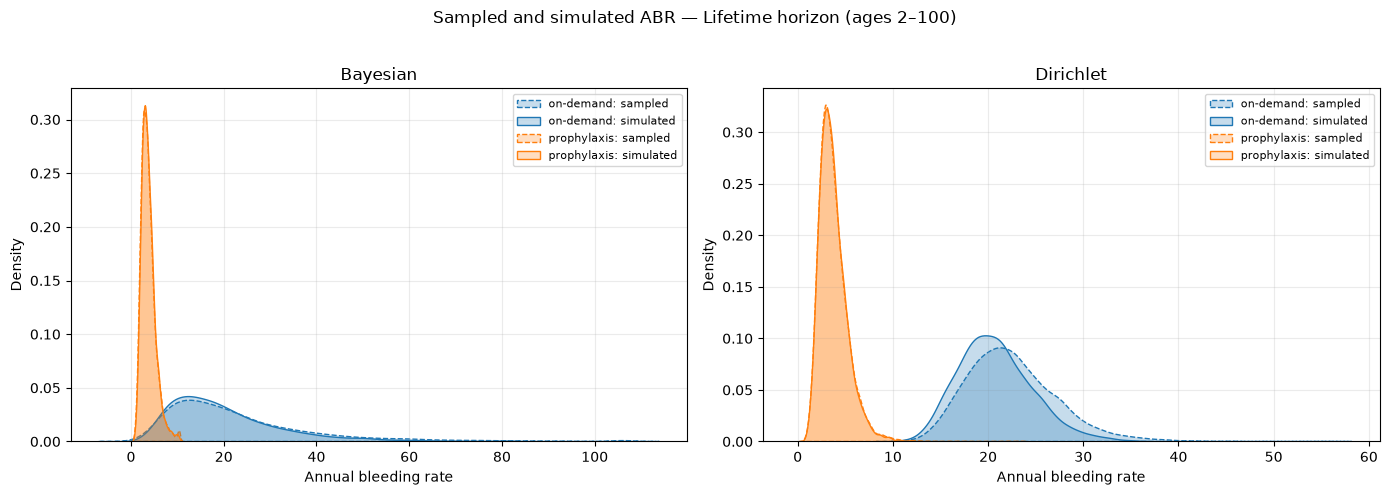

**Interpretation.** The plotted sampled and simulated bleeding distributions correspond to cohort ABRs ranging from 3.67 to 20.79.

**Conclusion.** Close alignment supports event-rate calibration; visible shifts between regimes represent the modelled prophylaxis effect.

## Survival Curve

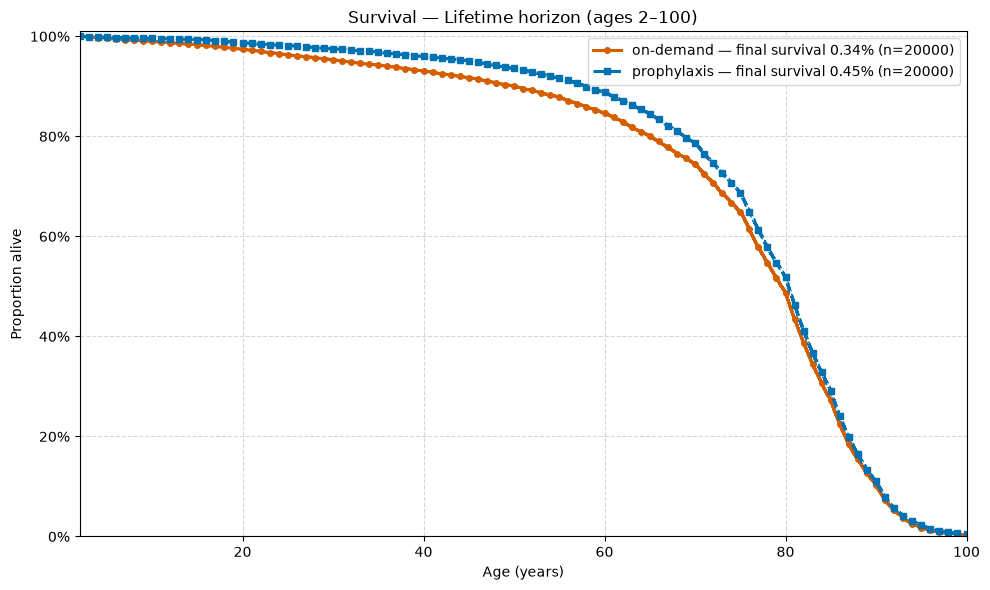

**Interpretation.** Childhood absorption ranges from 99.50 to 99.76%. The vertical axis is deliberately zoomed because survival remains high.

**Conclusion.** The empirical steps are Monte Carlo and weekly-event variation, not evidence of rapidly changing biological hazards; no smoothing is used.

## Health State Distribution

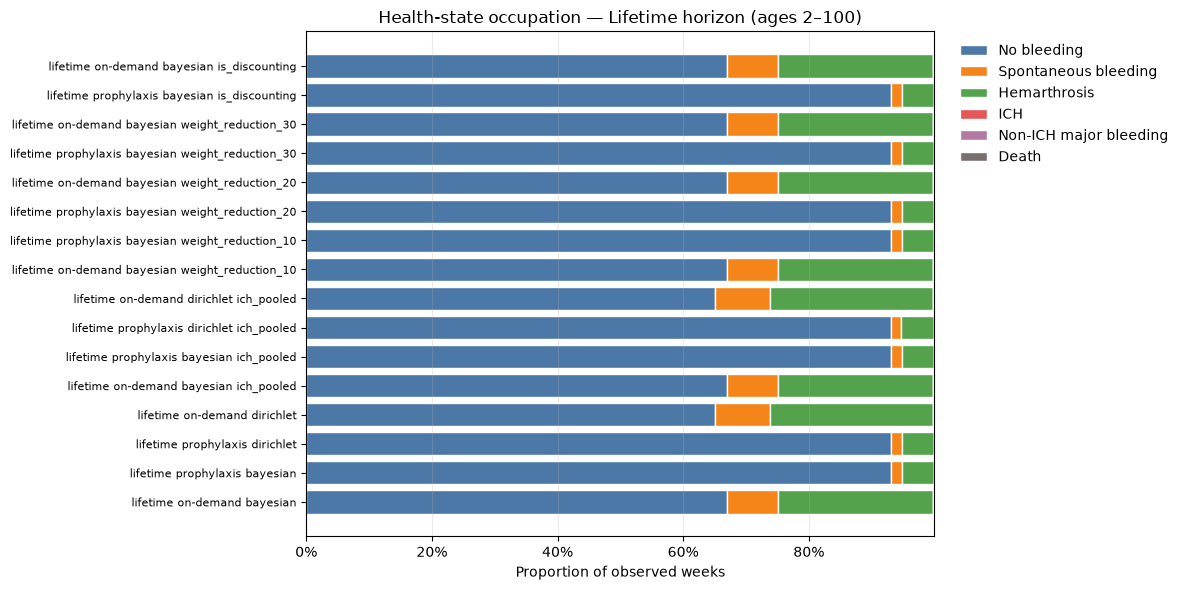

**Interpretation.** All plotted occupation vectors sum to one; maximum accounting error is 0.00e+00.

**Conclusion.** The chart validates allocation of simulated time across states, but transition probabilities require separate calibration and face-validity checks.

## Qaly Distribution

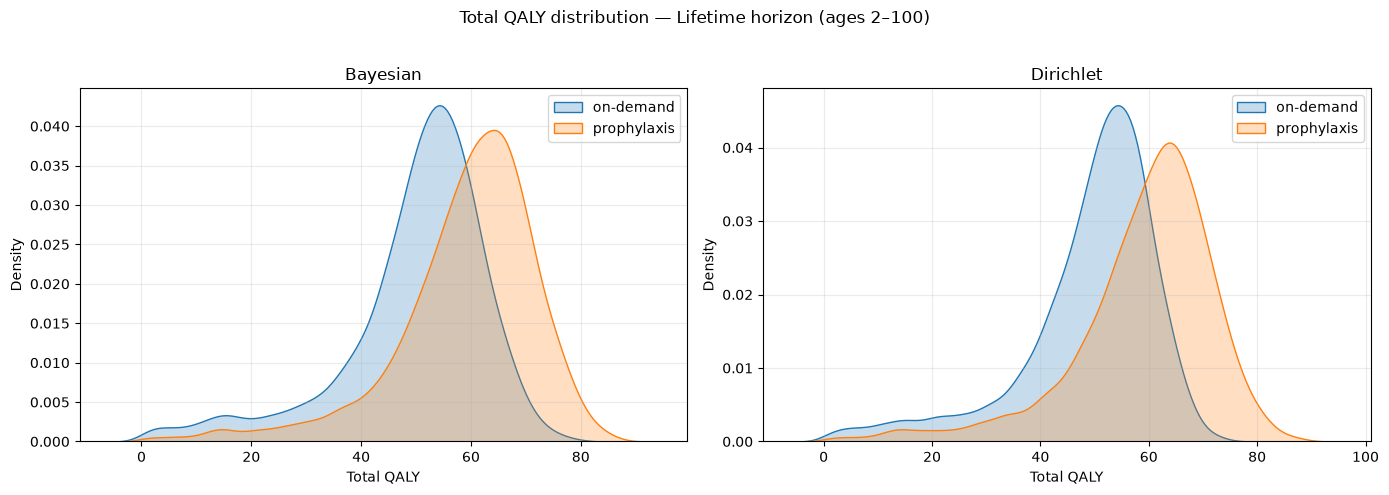

**Interpretation.** Scenario mean QALYs range from 13.87 to 59.25.

**Conclusion.** Distributional overlap shows individual uncertainty; paired incremental QALYs determine comparative effectiveness.

## Cost Distribution

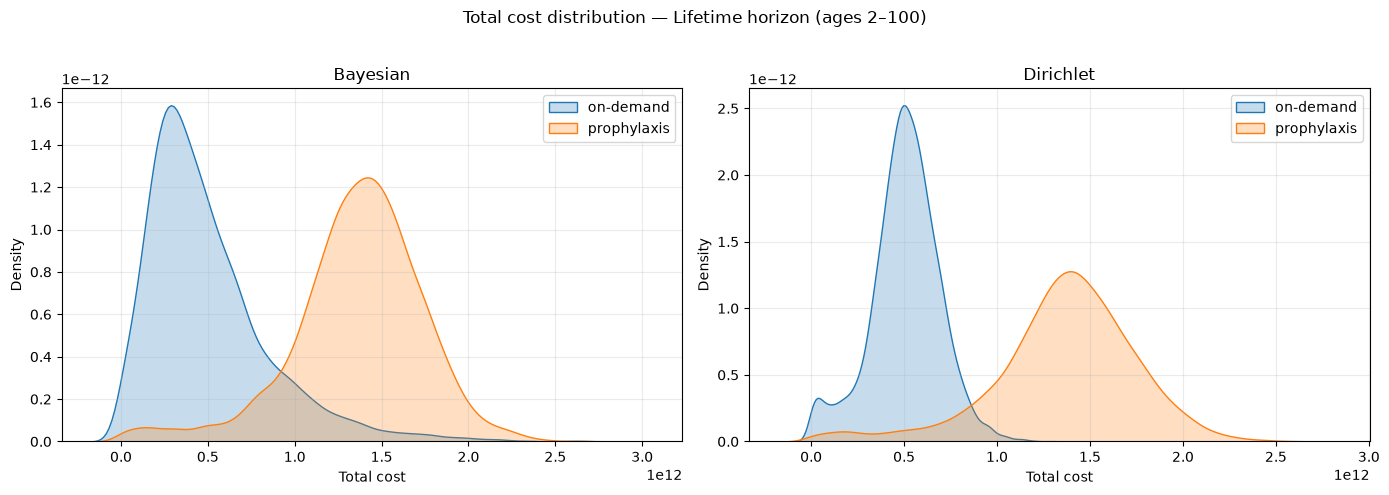

**Interpretation.** Scenario mean costs range from 80,364,135,213 to 1,363,650,863,510 IRR.

**Conclusion.** Separation largely reflects factor consumption and should be considered with health gains rather than interpreted alone.

## Joint Cost Qaly

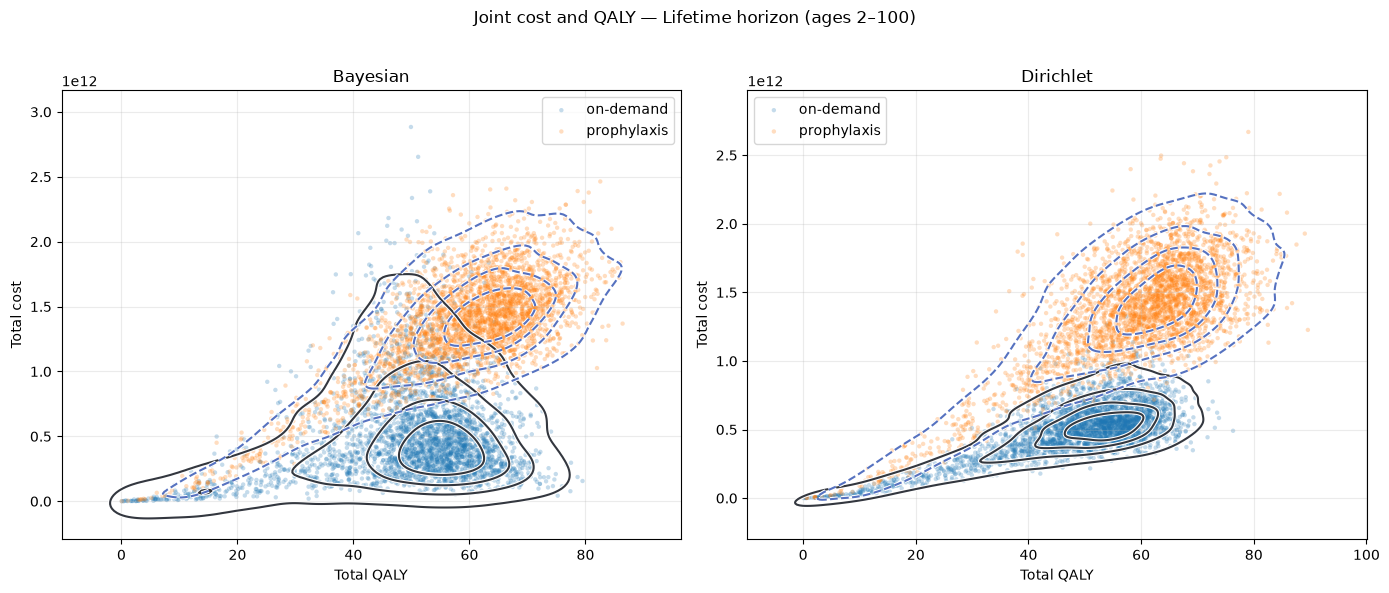

**Interpretation.** Points show individual PSA outcomes and contours identify their highest-density regions without replacing the underlying observations.

**Conclusion.** A favourable intervention shifts QALYs rightward; its vertical cost shift must then be assessed against the WTP boundary in the incremental plane.

## Cost Effectiveness Planes

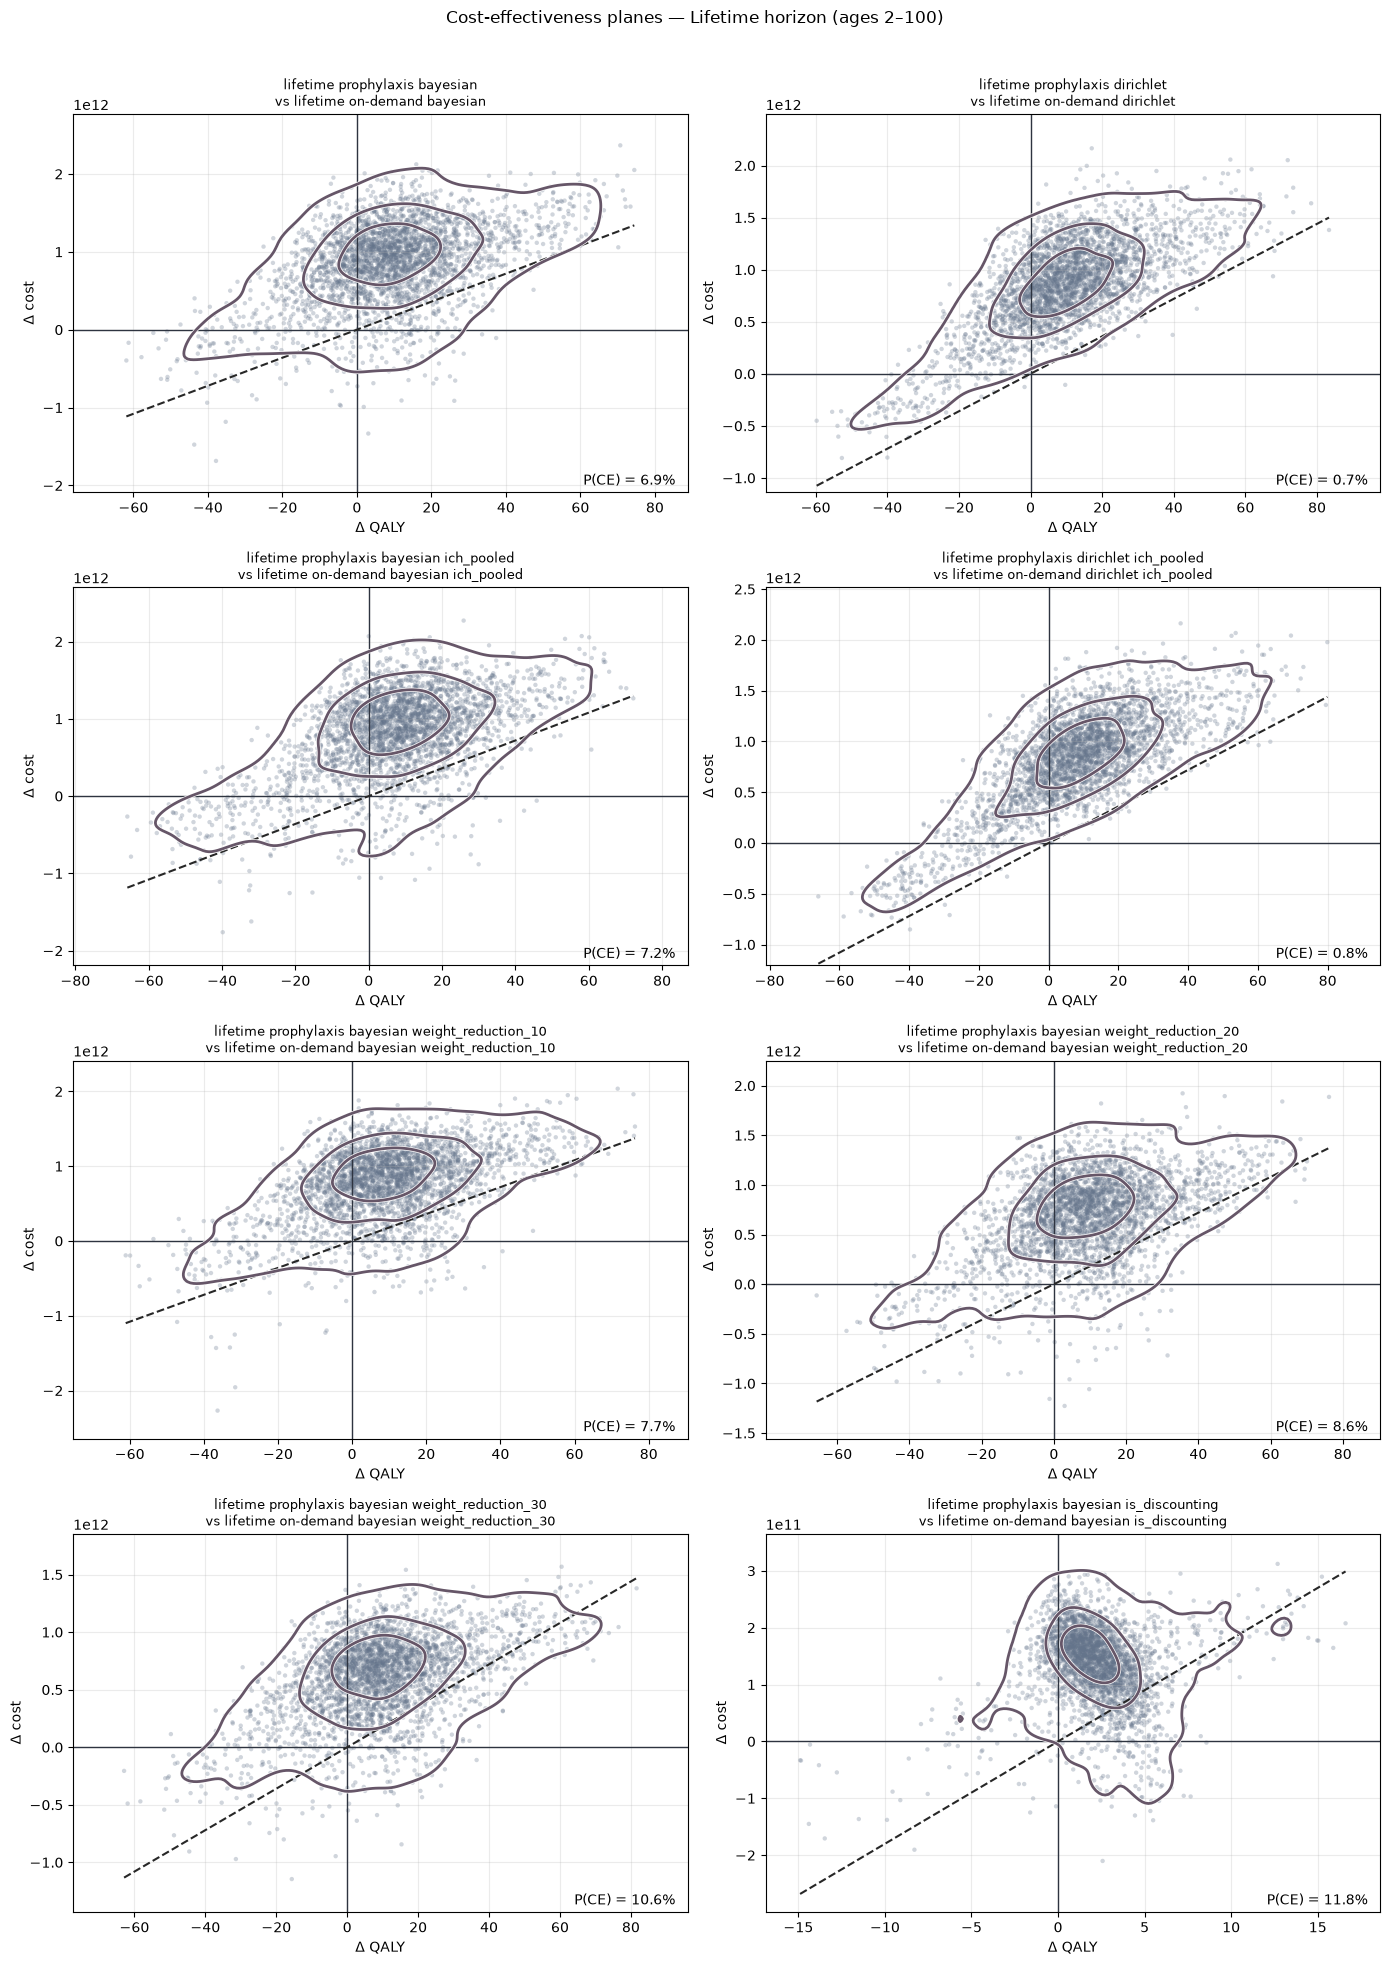

**Interpretation.** At 18,000,000,000 IRR/QALY, probabilities cost-effective range from 0.7% to 11.8%. Points below the WTP line have positive incremental NMB.

**Conclusion.** The plane preserves joint cost–effect uncertainty and is more informative than considering the marginal cost or QALY distributions separately.

## Icer Distributions

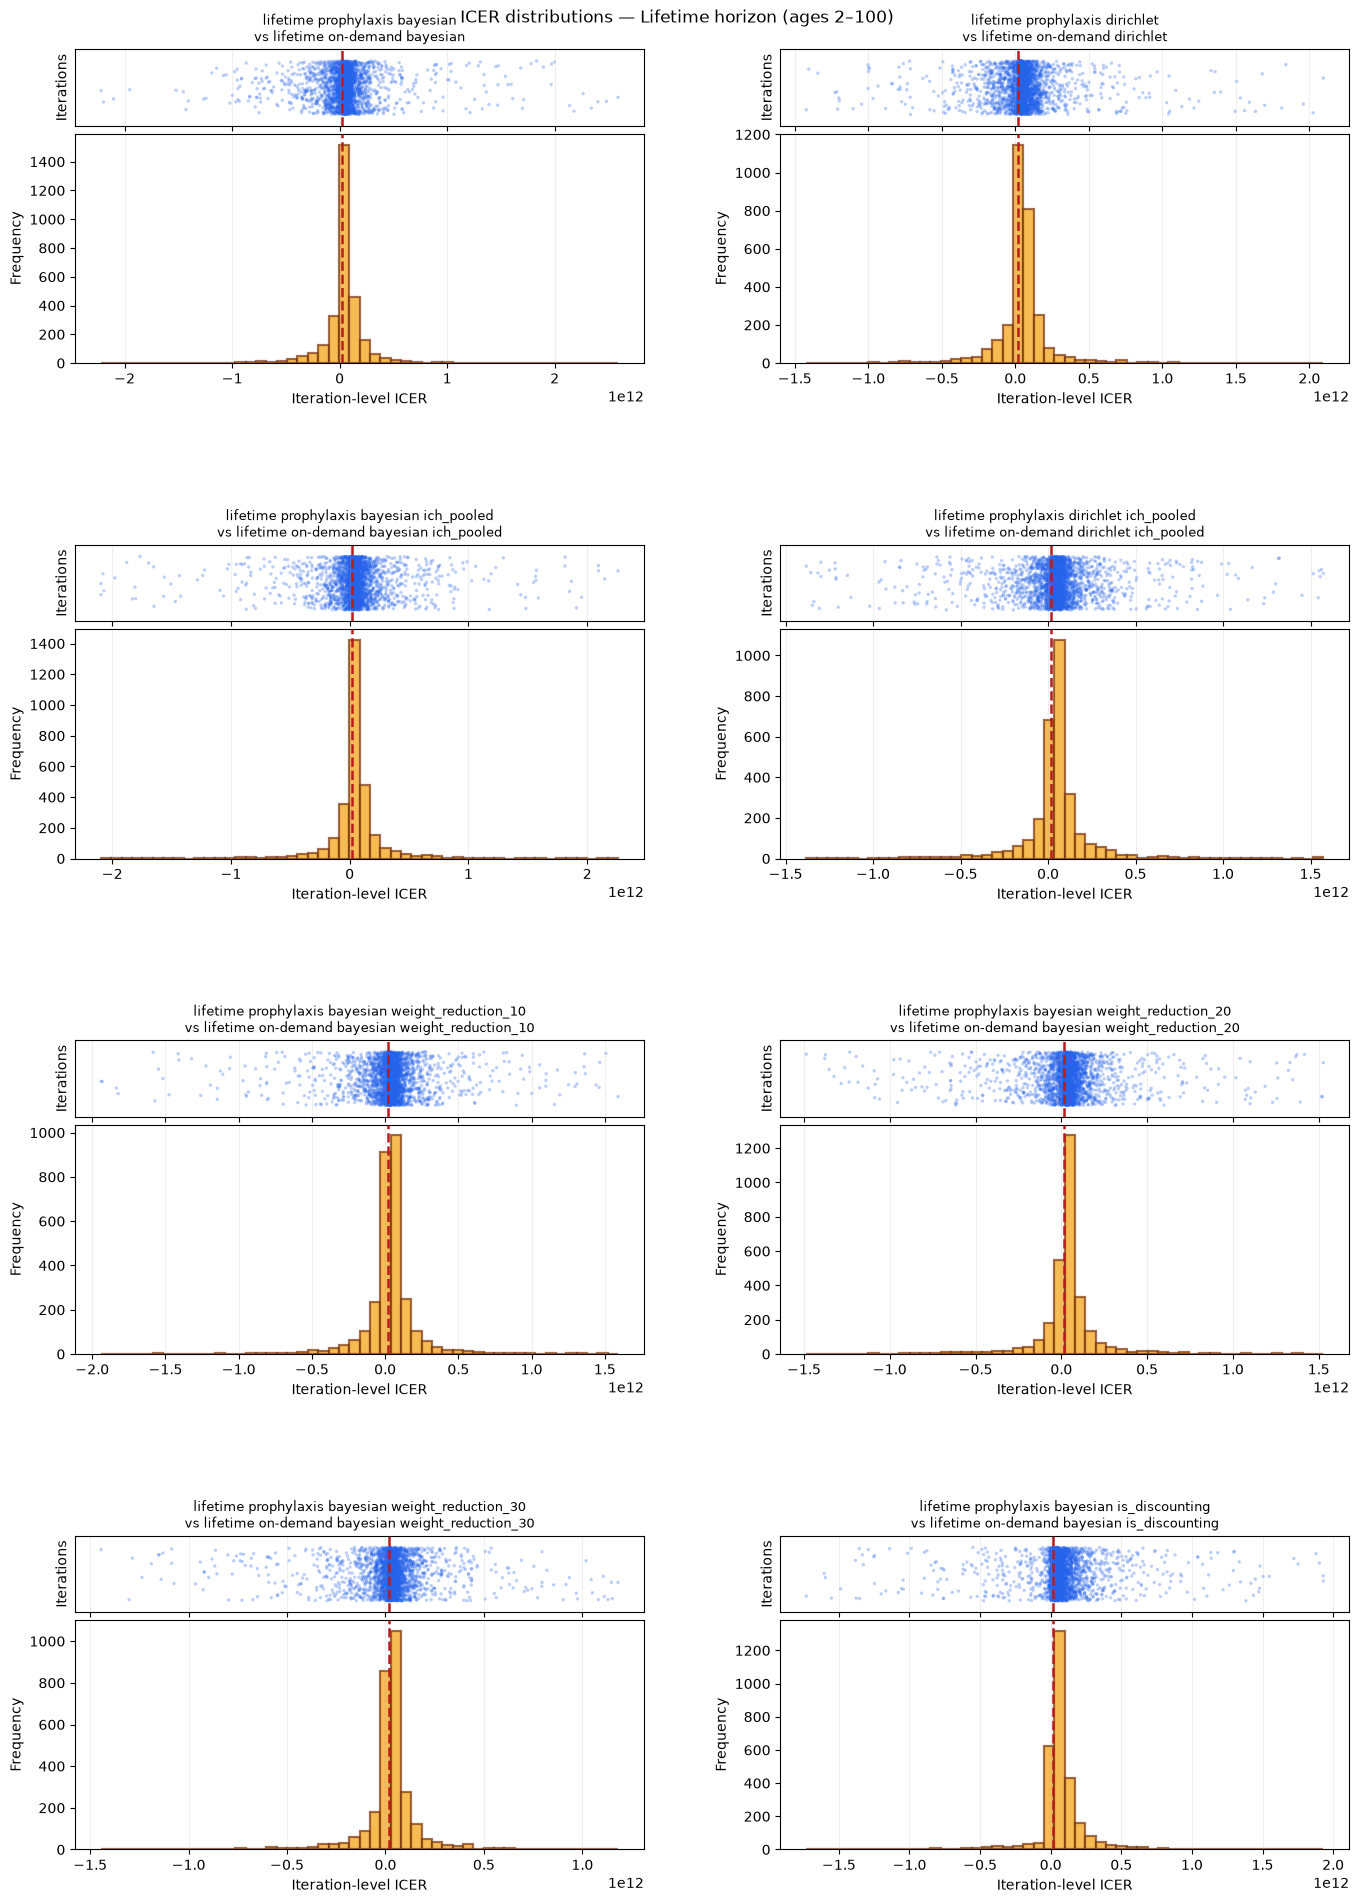

**Interpretation.** The upper strips show individual paired ICERs on the same x-scale as the histograms below; the displayed range excludes the outer 1% tails on each side.

**Conclusion.** Long or irregular tails are expected when incremental QALYs approach zero. Therefore, ICER histograms are descriptive and NMB is preferred for decisions.

## Ceac

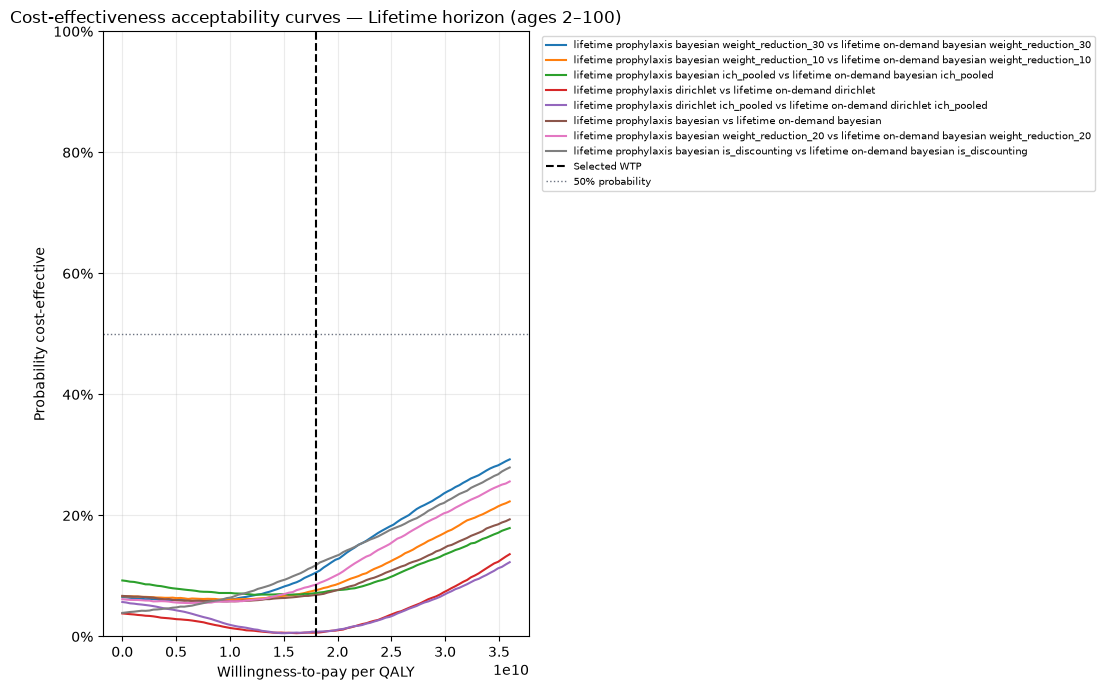

**Interpretation.** The selected WTP is 18,000,000,000 IRR/QALY. Fifty-percent CEAC thresholds range from not estimable IRR/QALY.

**Conclusion.** The CEAC expresses decision uncertainty over alternative WTP values; it does not identify a universally correct threshold.

## Incremental Nmb Distribution

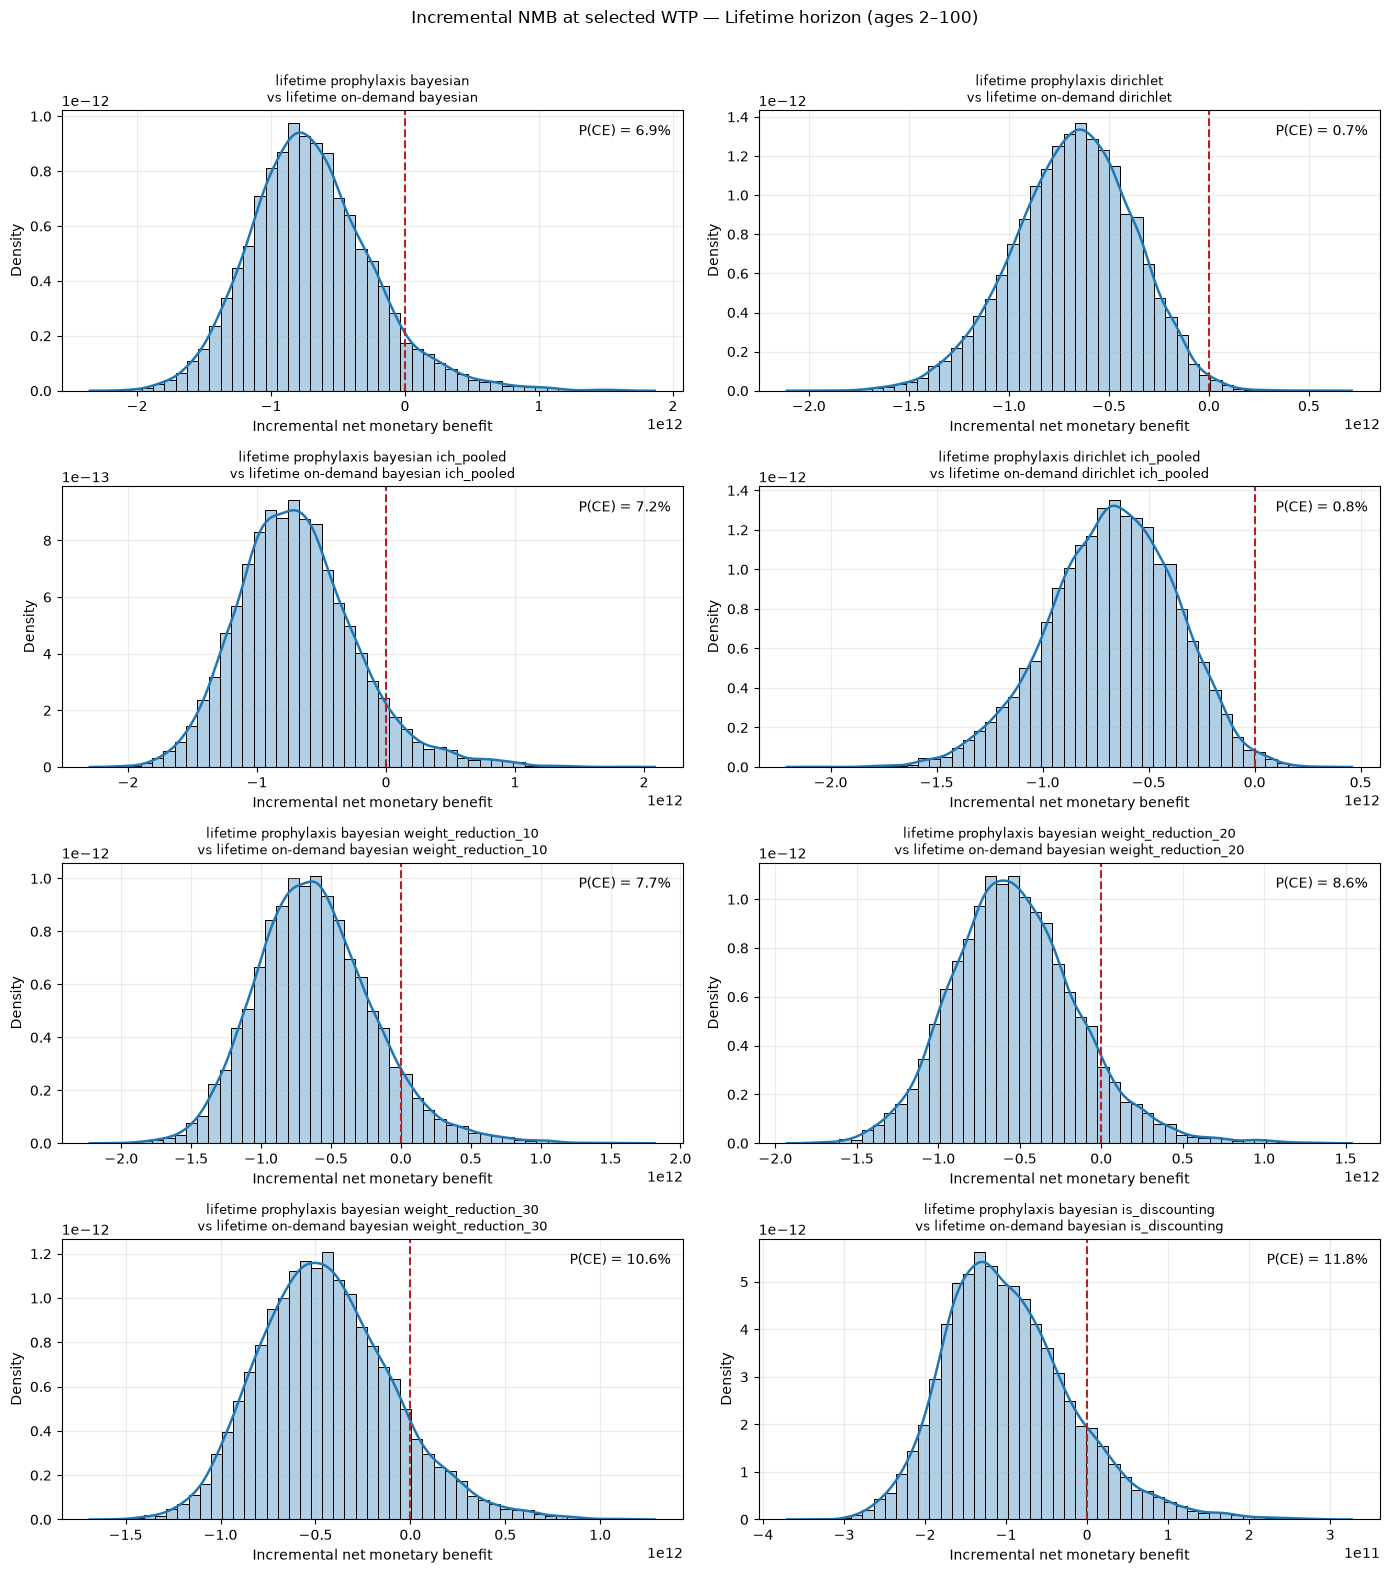

**Interpretation.** Mean incremental NMB ranges from -696,801,159,888 to -95,794,954,006 IRR at the selected WTP.

**Conclusion.** Values above zero favour prophylaxis. This is the primary probabilistic cost-effectiveness display because it remains interpretable across quadrants.

## Icer Vs Abr Threshold

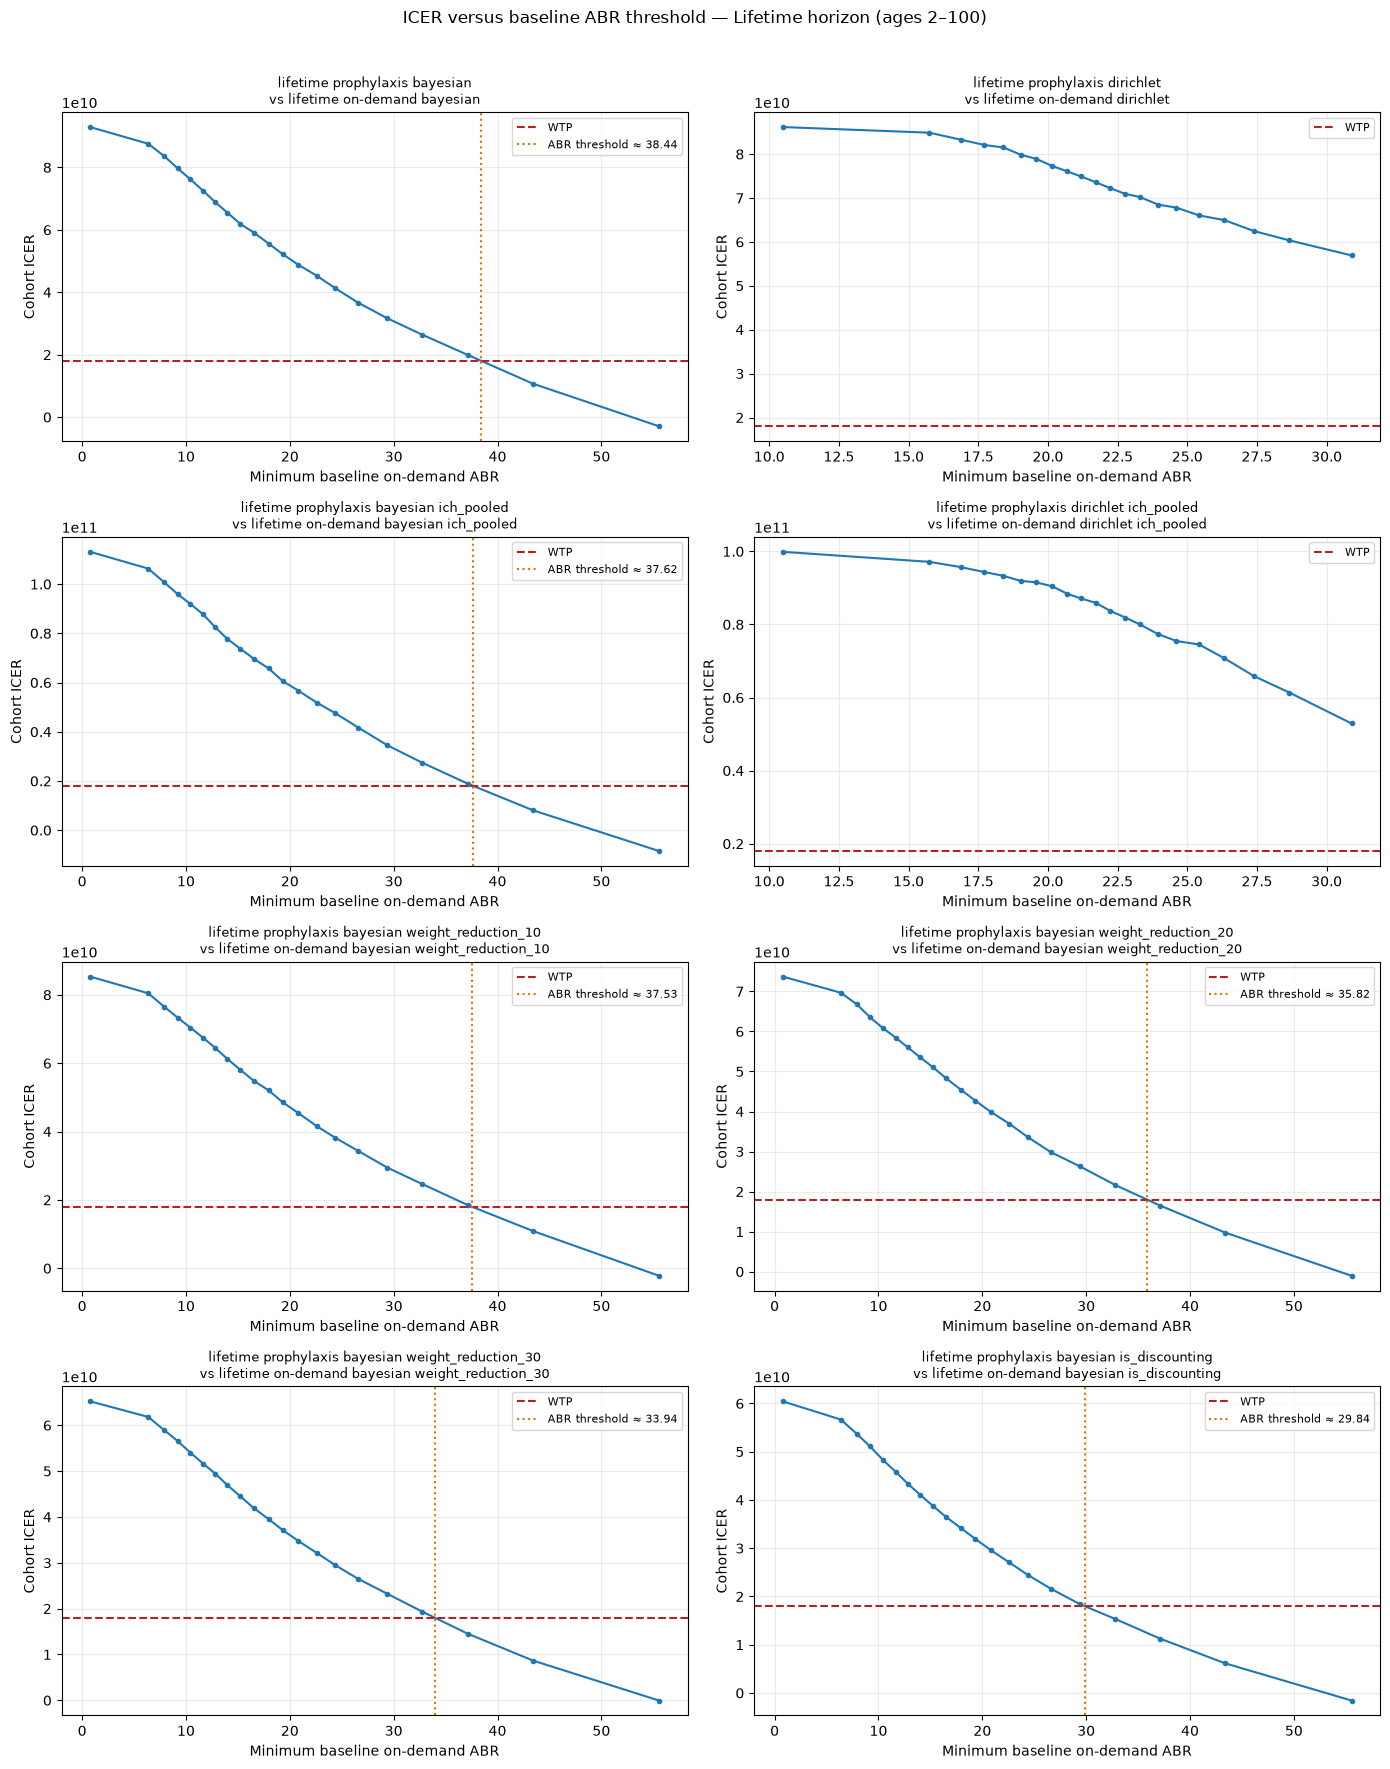

**Interpretation.** Estimated cost-effective baseline ABR thresholds range from 29.84 to 38.44.

**Conclusion.** The curves indicate how conclusions depend on baseline bleeding burden; only crossings inside the observed range should be interpreted.

In [3]:
figures = report.figures()
saved_figures = report.save_figures(figures)

for title, figure in figures.items():
    display(Markdown(f"## {title.replace('_', ' ').title()}"))
    display(figure)
    display(Markdown(report.interpret_figure(title, tables=tables)))
    plt.close(figure)

In [4]:
display(Markdown("## Saved figure files"))
for name, path in saved_figures.items():
    print(f"{name}: {path}")

## Saved figure files

abr_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\abr_distribution.png
survival_curve: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\survival_curve.png
health_state_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\health_state_distribution.png
qaly_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\qaly_distribution.png
cost_distribution: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\cost_distribution.png
joint_cost_qaly: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetime_age_2_100\joint_cost_qaly.png
cost_effectiveness_planes: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\psa\lifetim